In [1]:
import json
import os
import sys
import time
import pickle 

import numpy as np
import pandas as pd
import squidpy as sq
import scanpy as sc

import anndata as ad

from scipy.stats import spearmanr,pearsonr

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

import stipple as stp
from stipple.model import StippleModel

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


Helpers to load data and save results

In [2]:
def download_data(sample_id):

    def _download(prefix, output, file, strip=None):

        if strip: 
            output_file = file.split(strip)[1]
        else:
            output_file = file

        root, extension = os.path.splitext(output_file)
        if extension in ['.txt','.tsv']:
            output_file = root + '.csv'
        
        cmd = f'curl --create-dirs -o {output}/{output_file} {prefix}/{file}'
        print(cmd)
        return os.system(cmd)
        
    

    # Download h5 data
    prefix = 'https://spatial-dlpfc.s3.us-east-2.amazonaws.com/h5'
    file = f'{sample_id}_filtered_feature_bc_matrix.h5'
    output = f'../data/raw/{sample_id}'
    code = _download(prefix, output,  file)

    # Download histology data
    prefix = f'https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/Analysis/Histology/{sample_id}'
    file = f'tissue_spot_counts.csv'
    
    code = _download(prefix, output,  file)

    # download spatial data
    output = f'../data/raw/{sample_id}/spatial'

    # images
    prefix = f'https://spatial-dlpfc.s3.us-east-2.amazonaws.com/images'
    file = f'{sample_id}_tissue_hires_image.png'
    code = _download(prefix, output,  file, strip = f'{sample_id}_')
    
    file = f'{sample_id}_tissue_lowres_image.png'
    code = _download(prefix, output,  file, strip = f'{sample_id}_')

    # scale and tissue positions
    prefix = f'https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/10X/{sample_id}'
    file = 'scalefactors_json.json'
    code = _download(prefix, output,  file)
    
    file = 'tissue_positions_list.txt'
    code = _download(prefix, output,  file)

    return None
    

In [3]:
def load_visium(path, count_file: str) -> ad.AnnData:
    """
    Load a single Visium sample into an AnnData with obsm["spatial"]
    """

    
    adata = sq.read.visium(
          path,
          counts_file = count_file,
    )
    
    adata.obs['barcode'] = adata.obs.index
    adata.var_names_make_unique()
    
    return adata

    
def _unique_dir(path: str) -> str:
    """`path`, or `path` with a numeric suffix (_1, _2, ...) appended to
    its final component if it already exists -- run directories are
    never overwritten."""
    if not os.path.exists(path):
        return path
    parent, name = os.path.split(path)
    i = 1
    while True:
        candidate = os.path.join(parent, f"{name}_{i}")
        if not os.path.exists(candidate):
            return candidate
        i += 1


def _tidy_fitted_mean_variance(adata) -> pd.DataFrame:
    """Long/tidy format: one row per (observation, gene), columns
    obs_id/gene/fitted_mean/fitted_variance -- melts adata.obsm[
    "stipple_fitted_mean"/"stipple_fitted_variance"] ((N, G) each)."""
    
    mean_ig = np.asarray(adata.obsm["stipple_fitted_mean"])
    var_ig = np.asarray(adata.obsm["stipple_fitted_variance"])
    obs_ids = adata.obs_names.to_numpy()
    gene_names = adata.var_names.to_numpy()
    n, G = mean_ig.shape
    return pd.DataFrame({
        "obs_id": np.repeat(obs_ids, G),
        "gene": np.tile(gene_names, n),
        "fitted_mean": mean_ig.ravel(),
        "fitted_variance": var_ig.ravel(),
    })


Helper for QC of counts

In [4]:
def do_qc_prep(
    adata, 
    * ,
    min_max_val=4, 
    max_max_val=1_000,
    min_mean=0.38,
    min_cells=10,
    max_pct_dropout = 95,
    exclude_top=None,
    output_dir=None,
    copy=False
):

    # Filter to in tissue spots
    adata.obs['in_tissue'] = adata.obs['in_tissue'].astype(bool)
    adata = adata[adata.obs['in_tissue'],:]
    
    adata.var["mt"] = adata.var_names.str.startswith(("MT-","mt-"))
    adata.var["ribo"] =  adata.var_names.str.startswith(("RPS","RPL"))
    adata.layers['raw'] = adata.X.copy()
    
    adata.var['Symbol'] = adata.var.index

    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'],inplace=True)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    
    gene_dropout_pct_filter = adata.var['pct_dropout_by_counts'] < max_pct_dropout

    n, g = adata.shape
    means = adata.X.mean(axis=0).A1
    maxes = adata.X.max(axis=0).toarray().reshape(-1)
    
    gene_min_max_filter = (means >= min_mean) & (maxes <= max_max_val) & (maxes >= min_max_val)
    
    genes_keep_filter = gene_dropout_pct_filter & gene_min_max_filter & (~ adata.var["mt"].values)


    if exclude_top: 
        adata = adata[:, genes_keep_filter].copy()
        
        X = adata.X.copy()
        frac = X / adata.obs['total_counts'].values.reshape(-1,1)
        
        gene_idx_max = np.asarray(np.argmax(frac, axis=1)).flatten()
        high_expr_gene_excl = adata.var_names[gene_idx_max].value_counts().head(n=exclude_top).index.values
    
        print(f"Excluding the top {exclude_top} highest fraction genes:\n {high_expr_gene_excl}")
    
        import csv
       
        with open(os.path.join(output_dir,'exclude-genes.csv'), 'w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(high_expr_gene_excl)
    
        gene_high_expr_filter = adata.var_names.isin(high_expr_gene_excl)
        genes_keep_filter = (~gene_high_expr_filter)

    n_fit_genes = genes_keep_filter.sum()
    
    print(f"{n_fit_genes} / {g} available for fitting", flush=True)
    
    return adata[:, genes_keep_filter].copy() if copy else adata[:, genes_keep_filter]

In [5]:
sample_ids = [
    '151507', '151508', '151509', '151510',
    '151669', '151670', '151671', '151672',
    '151673', '151674', '151675', '151676'
]

Download layer/group annotations

In [6]:
layer_map_path = 'https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/10X/barcode_level_layer_map.tsv'
cmd = f" curl --create-dirs -o ../data/barcode_level_layer_map.tsv {layer_map_path}"

os.system(cmd)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1340k  100 1340k    0     0  9642k      0 --:--:-- --:--:-- --:--:-- 9642k


0

Load data for a speciifc sample and do QC

update `sample_id` to get results for other tissue slices

In [7]:
output_root = '../results'
dataset_id = 'libd'
sample_id = '151673'
run_id = 'stipple'

In [8]:
base_dir = os.path.join(output_root, dataset_id, sample_id, run_id)
out_dir = _unique_dir(base_dir)
os.makedirs(out_dir)

print(f"Writing results to {out_dir}", flush=True)

Writing results to ../results/libd/151673/stipple_1


In [9]:
download_data(sample_id)

curl --create-dirs -o ../data/raw/151673/151673_filtered_feature_bc_matrix.h5 https://spatial-dlpfc.s3.us-east-2.amazonaws.com/h5/151673_filtered_feature_bc_matrix.h5


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.2M  100 12.2M    0     0  8538k      0  0:00:01  0:00:01 --:--:-- 8532k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  192k  100  192k    0     0  1670k      0 --:--:-- --:--:-- --:--:-- 1670k


curl --create-dirs -o ../data/raw/151673/tissue_spot_counts.csv https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/Analysis/Histology/151673/tissue_spot_counts.csv
curl --create-dirs -o ../data/raw/151673/spatial/tissue_hires_image.png https://spatial-dlpfc.s3.us-east-2.amazonaws.com/images/151673_tissue_hires_image.png


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6004k  100 6004k    0     0  6314k      0 --:--:-- --:--:-- --:--:-- 6307k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

curl --create-dirs -o ../data/raw/151673/spatial/tissue_lowres_image.png https://spatial-dlpfc.s3.us-east-2.amazonaws.com/images/151673_tissue_lowres_image.png


100  472k  100  472k    0     0  1013k      0 --:--:-- --:--:-- --:--:-- 1013k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   162  100   162    0     0   1227      0 --:--:-- --:--:-- --:--:--  1236
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

curl --create-dirs -o ../data/raw/151673/spatial/scalefactors_json.json https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/10X/151673/scalefactors_json.json
curl --create-dirs -o ../data/raw/151673/spatial/tissue_positions_list.csv https://raw.githubusercontent.com/LieberInstitute/HumanPilot/refs/heads/master/10X/151673/tissue_positions_list.txt


100  182k  100  182k    0     0  1518k      0 --:--:-- --:--:-- --:--:-- 1518k


In [10]:
df_layers = pd.read_csv(
    os.path.join('../data/barcode_level_layer_map.tsv'), 
    names = ['barcode','sample','layer'], sep='\t')

df_layers['sample'] = df_layers['sample'].astype(str)

In [11]:
data_path = f"../data/raw/{sample_id}/"
data_file = f"{sample_id}_filtered_feature_bc_matrix.h5"

adata = load_visium(data_path, data_file)
print(f"Loaded {adata.n_obs} spots x {adata.n_vars} genes", flush=True)

/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded 3639 spots x 33538 genes


/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
adata = do_qc_prep(adata, output_dir = out_dir)

adata.obs['sample'] = sample_id

/tmp/ipykernel_2064151/3869152862.py:18: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith(("MT-","mt-"))


2127 / 16578 available for fitting


/tmp/ipykernel_2064151/2237603964.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = sample_id


In [13]:
adata.obs = pd.merge(adata.obs, df_layers, on=['barcode','sample'], how='left')

adata.obs = adata.obs.set_index('barcode',drop=True)
adata.obs.index.name = None

adata = adata[~adata.obs['layer'].isna(),:]

print(f"QC complete! Fitting {adata.n_obs} spots x {adata.n_vars} genes", flush=True)

QC complete! Fitting 3611 spots x 2127 genes


/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
n,g = adata.shape

Estimate mean capture probability in assay

In [15]:
tc = adata.obs['total_counts'].values
q = tc / np.mean(tc)

tk_i = adata.obs.groupby('layer')['total_counts'].transform('mean').values
tk  = adata.obs.groupby('layer')['total_counts'].mean().values
nk = adata.obs.groupby('layer')['total_counts'].size().values

scalars = (q/n/tk_i) * sum(nk*tk)
if max(scalars) < 1 :
    print("Max scalar is less than 1, estimate of MU_0 is invalid. Model is incorrect")
    
MU_0 = 1 / np.max(scalars)

print(f'Known capture rate set to: {MU_0}', flush=True)

Known capture rate set to: 0.29239382422135424


Model parameters/arguments

In [16]:
fine_resolution_dict = {
    'n_knots_target': n*2,
    "radius_overlap_factor": 1.5
}
coarse_resolution_dict = None

       
model_kwargs = dict(
        group_key="layer",
        likelihood='negbinomial',
        sigma2 = 1.0, 
        fine_resolution=fine_resolution_dict,
        coarse_resolution=coarse_resolution_dict,
        gene_batch_size=100
    )

Run stipple

In [17]:
model = StippleModel(
    adata, 
    known_capture_rate=MU_0, 
    num_threads=16,
    verbose=True,
    **model_kwargs
)

t0 = time.perf_counter()
model.fit(n_iterations=3_000, convergence_tol=1e-5)
fit_seconds = time.perf_counter() - t0

model.set_anndata_results(adata)

converged = bool(model._converged)
print(f"Fit finished in {fit_seconds:.1f}s (converged={converged})", flush=True)

[stipple] preprocessing data


/home/kayla-jackson/projects/stipple/stipple/model/data.py:135: UserWarning: hexagonal-to-oblique coordinate transform has larger-than-expected residuals for 7.4% of points; the detected lattice orientation may be inaccurate
  coords_transformed, inverse_transform = grid.to_grid_coordinates(coords_raw, grid_info)
/home/kayla-jackson/projects/stipple/stipple/model/stipple_model.py:168: UserWarning: materializing a dense 3611x2127 count matrix (7680597 entries) for the likelihood -- this may use significant memory for large gene panels
  self.data = _data.preprocess(adata, group_key)


[stipple] detected hexagonal grid, spacing=137, 3611 locations, 2127 genes, 7 groups
[stipple] built basis: 1 resolution(s), M=7469 total (bisquare:7469)
[stipple] iteration 0: objective = -12881326.2868
[stipple] iteration 5: objective = -13517018.7957
[stipple] iteration 10: objective = -12221981.2647
[stipple] iteration 15: objective = -12209745.1048
[stipple] iteration 20: objective = -13563926.3941
[stipple] iteration 25: objective = -13279889.4640
[stipple] iteration 30: objective = -12980296.9896
[stipple] iteration 35: objective = -12257016.1239
[stipple] iteration 40: objective = -12737179.8619
[stipple] iteration 45: objective = -12853200.3165
[stipple] iteration 50: objective = -12099916.0279
[stipple] iteration 55: objective = -12930637.9135
[stipple] iteration 60: objective = -12478766.6066
[stipple] iteration 65: objective = -11816737.8421
[stipple] iteration 70: objective = -12160185.2822
[stipple] iteration 75: objective = -13510366.6042
[stipple] iteration 80: objectiv

/home/kayla-jackson/projects/stipple/stipple/model/stipple_model.py:503: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["stipple_p_hat"] = self.get_capture_rates()


Fit finished in 104.2s (converged=True)


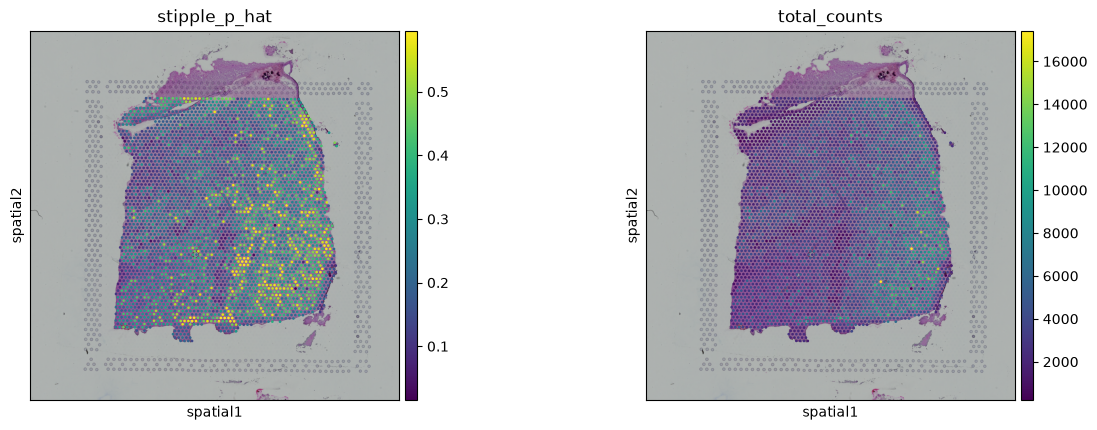

In [18]:
sq.pl.spatial_scatter(
    adata,
    color=['stipple_p_hat', 'total_counts']
)
            

Write results

In [19]:
model.write_gene_params_csv(os.path.join(out_dir, "gene_level.csv"))
model.write_observation_csv(adata, os.path.join(out_dir, "observation_level.csv"))

_tidy_fitted_mean_variance(adata).to_csv(os.path.join(out_dir, "fitted_mean_variance.csv"), index=False)

...and save the model object

In [20]:
with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(model, f)

Do DE and classify genes

In [21]:
wald_result, _ = stp.tools.group_de_wald_test(
    model, 
    delta=1.0, 
    fdr_method='qvalue',
    propagate_capture_rate_uncertainty=False
)

wald_result['group_key'] = np.min(wald_result[['group', 'reference_group']],axis=1) + np.max(wald_result[['group', 'reference_group']],axis=1) + wald_result.gene
wald_result.to_csv(os.path.join(out_dir, 'group_de.csv'),index=False)

[stipple] computing block Fisher information standard errors for mu_gk/phi_gk
[stipple] block Fisher information standard errors computed


Classify genes

There is a difference in the squidpy (Python) and spdep (R) implementations of Moran's I that I have yet to track down. This affects classification of genes that are on the "borderline" of the $0.2$ cutoff. The estimates of Moran's I are within $10^{-3}$ of each other between the two implementations, but 12 or so classification labels switch between DVG +/- Field-aligned SVG. The difference is whether the genes are called field aligned, not whether they are DVG.

In [22]:
result,moran = stp.tools.classify_spatial_variable_genes(model, wald_result)

result["classification"].value_counts()          # counts per label

INFO     Creating graph using `None` transform and `1` libraries.                                                  


classification
DVG                    1777
Null Gene               236
DVG + Field aligned     101
SVG                      12
Field aligned             1
Name: count, dtype: Int64

In [23]:
moran.head()

,gene,moran_stage1,moran_stage2,classification
0,SDF4,0.047060,0.016789,Null Gene
1,ACAP3,0.033840,-0.009288,DVG
2,AURKAIP1,0.053333,-0.013461,DVG
3,MRPL20,0.062044,-0.002915,DVG
4,SSU72,0.048781,-0.000322,DVG


Update the anndata object with the gene classifications, then save

In [24]:
adata.var = adata.var.merge(result, left_index=True, right_on="gene",how='left')
adata.var_names=adata.var.Symbol.values

/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [25]:
adata.write_h5ad(os.path.join(out_dir, "adata.h5ad"))

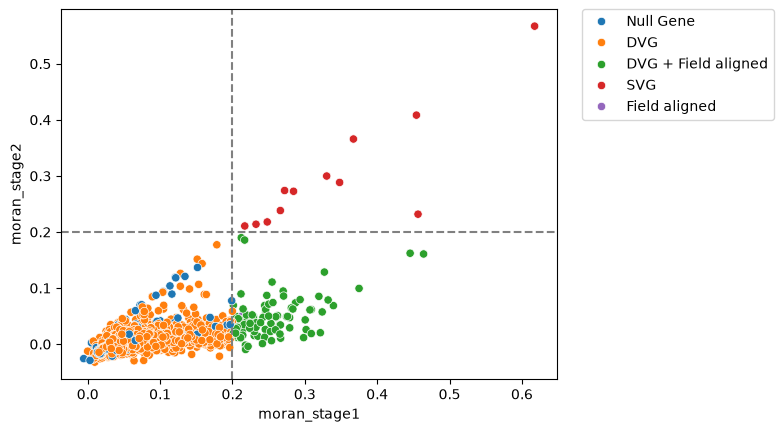

In [26]:
plt.axhline(y=0.2, color="gray", linestyle="--", linewidth=1.5)
plt.axvline(x=0.2, color="gray", linestyle="--", linewidth=1.5)

sns.scatterplot(
    data=moran,
    x="moran_stage1", 
    y="moran_stage2",
    hue='classification'
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

Add residuals to anndata object and plot

In [27]:
stp.tools.set_residual_layers(model, adata)

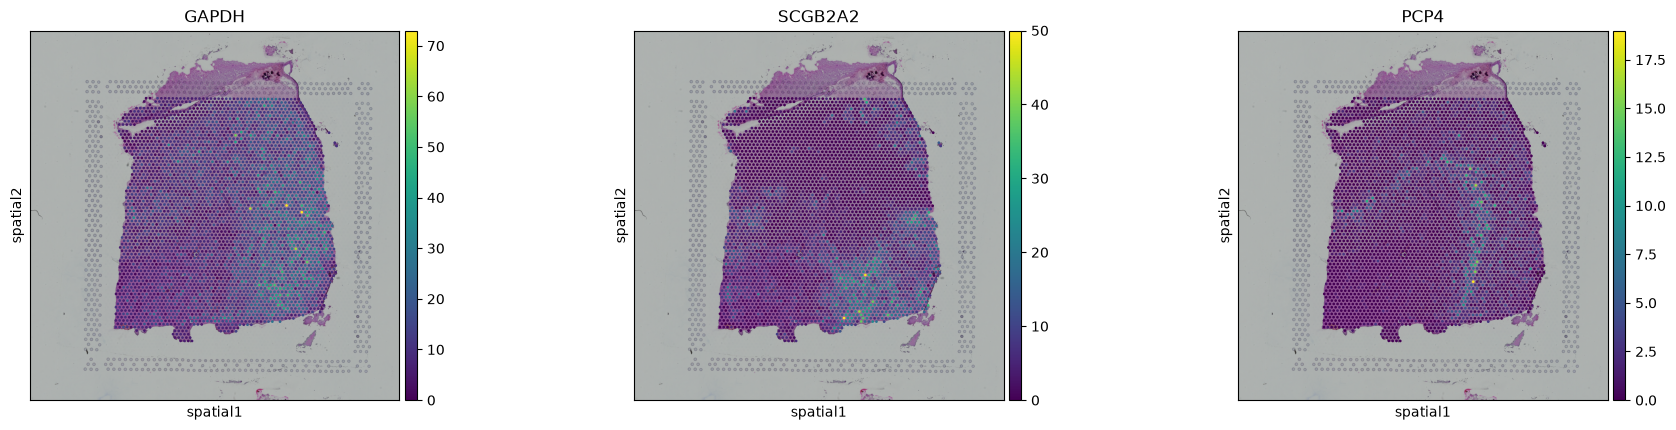

In [29]:
sq.pl.spatial_scatter(adata, color=["GAPDH", "SCGB2A2", "PCP4"])

In [30]:
indx, = np.where(adata.var_names.isin(["GAPDH", "SCGB2A2", "PCP4"]))

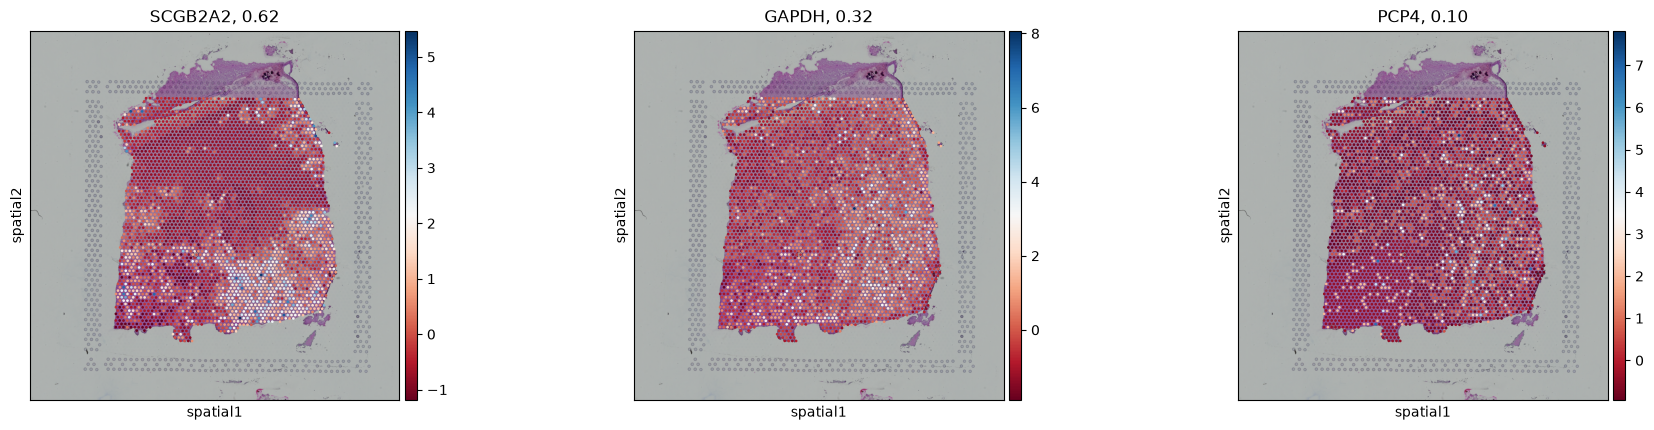

In [31]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

plot_titles = [f"{gene}, {val:.2f}"for gene, val in zip(adata.var_names[indx], moran.iloc[indx,:].moran_stage1)]
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "stipple_pearson_residuals_naive"),
    color=indx.astype(str),
    cmap='RdBu',
    title = plot_titles
)

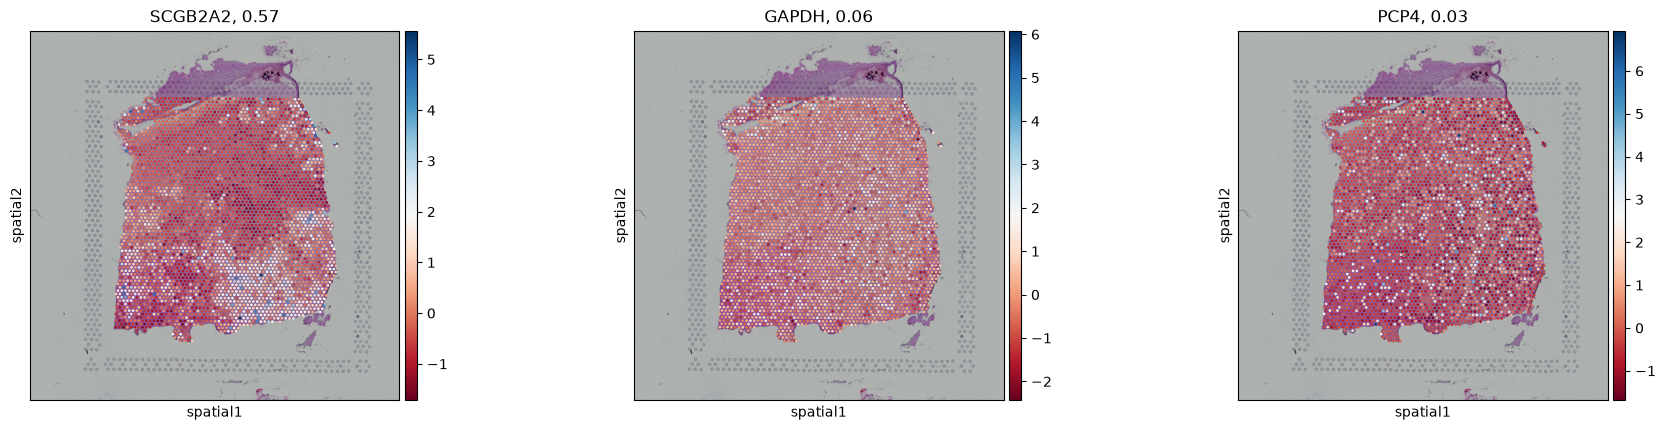

In [32]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

plot_titles = [f"{gene}, {val:.2f}"for gene, val in zip(adata.var_names[indx], moran.iloc[indx,:].moran_stage2)]
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "stipple_capture_rate_ols_residuals_naive"),
    color=indx.astype(str),
    cmap='RdBu',
    title = plot_titles
)


Plot nuclei per spot vs estimated p 

In [33]:
df_nuc = pd.read_csv(os.path.join(data_path, 'tissue_spot_counts.csv'))
df_nuc.head()

,barcode,tissue,row,col,imagerow,imagecol,count
0,ACGCCTGACACGCGCT-1,0,0,0,2427,2811,0
1,TACCGATCCAACACTT-1,0,1,1,2547,2879,0
2,ATTAAAGCGGACGAGC-1,0,0,2,2428,2949,0
3,GATAAGGGACGATTAG-1,0,1,3,2548,3017,0
4,GTGCAAATCACCAATA-1,0,0,4,2429,3086,0


In [34]:
adata.obs = adata.obs.merge(df_nuc, how='left', left_index=True, right_on='barcode')

/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [35]:
adata.obs['p_hat_rank'] = adata.obs['stipple_p_hat'].rank(method='first')

<Axes: xlabel='p_hat_rank', ylabel='count'>

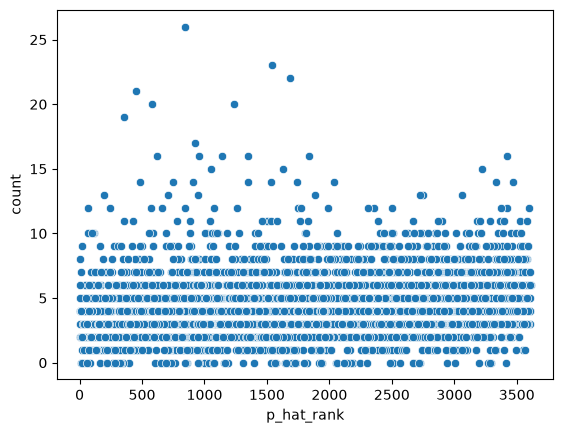

In [36]:
sns.scatterplot(
    data=adata.obs, 
    x="p_hat_rank", 
    y="count"
)

In [37]:
rho, _ = spearmanr(adata.X.toarray(), adata.obs['stipple_p_hat'].values)

In [38]:
adata.var['raw_count_cor_with_p'] = rho[:-1,2127]

How does correlation with the field change after normalizing the counts?

In [39]:
sc.pp.normalize_total(adata)

In [40]:
rho, _ = spearmanr(adata.X.toarray(), adata.obs['stipple_p_hat'].values)
adata.var['norm_count_cor_with_p'] = rho[:-1,2127]

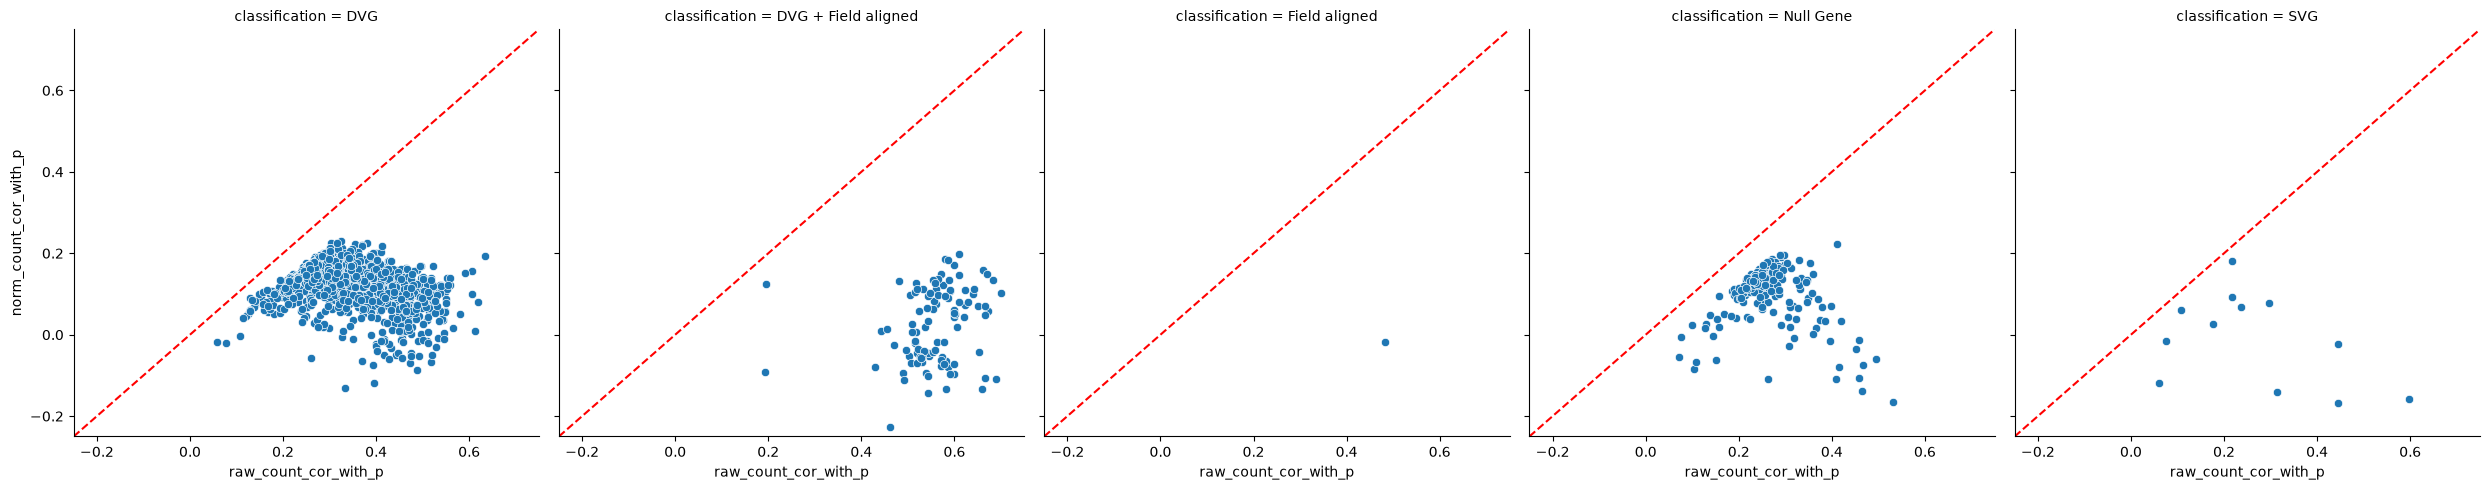

In [41]:
g = sns.relplot(
    data=adata.var, 
    x="raw_count_cor_with_p", 
    y="norm_count_cor_with_p", 
    col="classification", 
    kind="scatter")


g.map(
    plt.axline, 
    xy1=(0, 0), 
    slope=1, 
    color="red", 
    linestyle="--", 
    linewidth=1.5
)

g.set(
    xlim=(-0.25, 0.75), 
    ylim=(-0.25, 0.75))

plt.show()
